# Approximate Level Transition Strain Form

In [6]:
# %load functions_henry.py
## simple cut and paste of functions from henry's code, to be used in the notebook.
import math
import numpy as np

#### Universal constants

Mp = 1.220890e19
G = 1 / Mp**2
M_sun = 2e30 * 5.61e26

M_ann = 3.1e-04  # in solar masses
mua_ann = 2e-16  # in GeV
a_ann = 0.999999
alpha_ann = G*M_ann*mua_ann

M_tr = 1e-06     # in solar masses
mua_tr = 1e-13   # in GeV
a_tr = 0.999999
alpha_tr = G*M_tr*mua_tr



### Universal functions



def Omega_plus(a, r):
    return a / (2 * r)

def r_plus(M, a):
    return M * (1 + np.sqrt(1 - a**2)) * G

def gamma_a(l, alpha, M):
    if l == 1:
        p = 17
    else:
        p = 4 * l + 1
    rg = G * M
    return G * 1e-10 / rg**3 * (((alpha / l) * 0.5)**p + ((alpha / l) * 0.5)**(p + 1))

def gamma_t(ng,ne, mu, alpha, M):
    rg = G*M
    rc = ne**2 / alpha**2 * rg
    omega = 0.5* mu * alpha**2*(1/ng**2-1/ne**2)
    return 2 * G * omega**5 / 5 * mu**2 * rc**4


def glm(a, m, l, r, omega):
    g = 1
    if l == 1:
        g *= l**2 * (1 - a**2) + (a * m - 2 * r * omega)**2
    if l != 1:
        for k in range(1, l):
            g *= k**2 * (1 - a**2) + (a * m - 2 * r * omega)**2
    return g

def super_gamma(n, l, m, omega, mu, M, r, a):
    C = (
        2**(4 * l - 1)
        * math.factorial(n + l)
        / (n**(2 * l + 4) * math.factorial(n - l - 1))
        * (math.factorial(l) / (math.factorial(2 * l) * math.factorial(2 * l + 1)))**2
    )
    g = glm(a, m, l, r, omega)
    omega_plus = Omega_plus(a, r)
    gamma_nlm = (
        2 * r / M * C * g * (m * omega_plus - omega) * (G * mu * M)**(4 * l + 5) / G 
    )
    return gamma_nlm

# Annihilation Functions

def gamma_a(l, alpha, M):
    if l == 1:
        p = 17
    else:
        p = 4 * l + 1
    rg = G * M
    return G * 1e-10 / rg**3 * (((alpha / l) * 0.5)**p + ((alpha / l) * 0.5)**(p + 1))

def omega_ann(mua, alpha, n):
    return 2 * mua * (1 - alpha**2 / (2 * n**2))


def N_max(M):
    # Arvanitaki Eq 8, approximation
    return 10**(76)*(M/10)**2





##### Level Transition Frequency Domain Strain


def N_g_omega (omega, gamma_g,gamma_t, N_e,T):
    return 1/(gamma_g+gamma_t*N_e- 1j*omega)/(2*np.pi)*(1-np.exp(gamma_g+gamma_t*N_e- 1j*omega/(2*np.pi))*T)

def N_e_omega (omega, gamma_e,gamma_t, N_g,T):
    return 1/(gamma_e+gamma_t*N_g- 1j*omega/(2*np.pi))*(1-np.exp(gamma_e+gamma_t*N_g- 1j*omega/(2*np.pi))*T)

def h_tr(r,omega_tr,gamma_e,gamma_g,gamma_tr, T, omega,N_e,N_g): 
    # may need to fix expression due to complex factor in exponential
   
    return 1/np.sqrt(2*np.pi)*np.sqrt(4*G/(r**2*omega_tr) *gamma_tr *Ng*Ne) / ((gamma_g+gamma_e+gamma_tr*N_e-gamma_tr*N_g)- 1j*omega/(2*np.pi))*(1-np.exp(  (gamma_g+gamma_e+gamma_tr*N_e-gamma_tr*N_g)*T - 1j* omega/(2*np.pi) ))


####

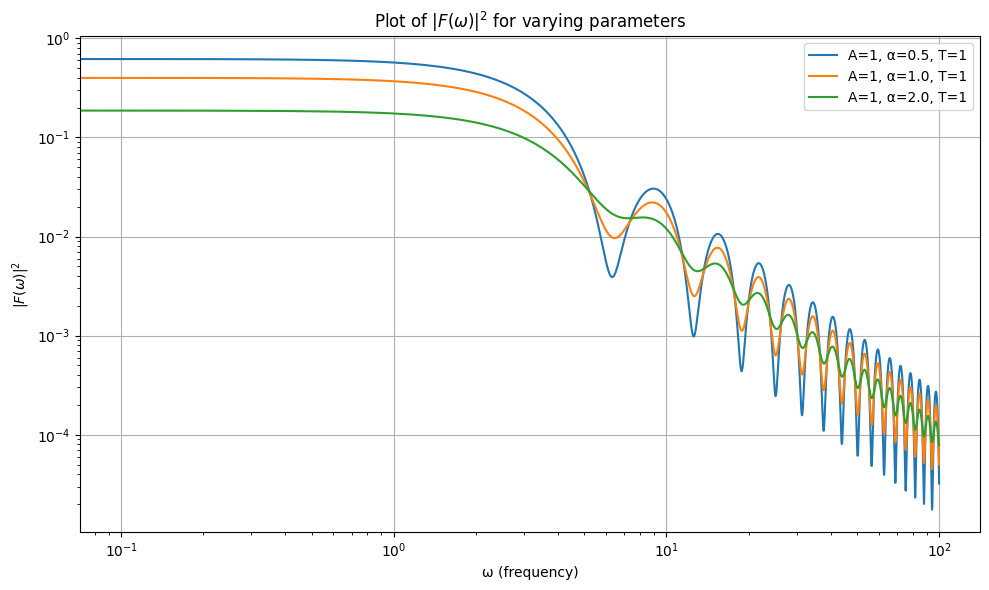

In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt

def F_squared(omega, A, alpha, T):
    numerator = A**2
    denominator = alpha**2 + omega**2
    exp_term = np.exp(-alpha * T)
    bracket = 1 - 2 * exp_term * np.cos(omega * T) + np.exp(-2 * alpha * T)
    return (numerator / denominator) * bracket

def plot_F_squared(
    A_vals=[1], alpha_vals=[1], T_vals=[1], 
    omega_range=(-10, 10), num_points=1000
):
    omega = np.linspace(*omega_range, num_points)
    
    plt.figure(figsize=(10, 6))
    for A in A_vals:
        for alpha in alpha_vals:
            for T in T_vals:
                y = F_squared(omega, A, alpha, T)
                label = f"A={A}, α={alpha}, T={T}"
                plt.plot(omega, y, label=label)

    plt.xlabel("ω (frequency)")
    plt.ylabel(r"$|F(\omega)|^2$")
    plt.yscale('log')
    plt.xscale('log')
    plt.title(r"Plot of $|F(\omega)|^2$ for varying parameters")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_F_squared(
A_vals=[1],
alpha_vals=[0.5, 1.0, 2.0],
T_vals=[1],
omega_range=(0, 1e2)
)


# Superradiance Transition Rates

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
Mp = 1.220890e19
G = 1 / Mp**2           # Newton's G in GeV^-2
gev_to_hz = 6.582119569e-25 # GeV to Hz
M_sun = 1.989e30 * 5.61e26  # Solar mass in GeV
Mpc_to_Gev = 1.56e38        # 1 Mpc in GeV
kpc_to_Gev = Mpc_to_Gev / 1000

# --- Level Transition Parameters ---
ne, ng = 6, 5
l = m = ng - 1
r_kpc = 1
r = r_kpc * kpc_to_Gev
M_tr = 1e-6 * M_sun
mu_a = 1e-13  # GeV
a_tr = 0.999999
alpha_tr = G * M_tr * mu_a

# --- Transition Frequency ---
omega_tr = 0.5 * mu_a * alpha_tr**2 * (1/ng**2 - 1/ne**2)

# --- Frequency Range (GeV) ---
omega = np.logspace(-31, -27, 10000)

# --- Compute Gamma values for each omega ---
gamma_e_vals = np.array([super_gamma(ne, l, m, w, mu_a, M_tr, r_plus(M_tr, a_tr), a_tr) for w in omega])
gamma_g_vals = np.array([super_gamma(ng, l, m, w, mu_a, M_tr, r_plus(M_tr, a_tr), a_tr) for w in omega])
gamma_tr_val = gamma_t(ng, ne, mu_a, alpha_tr, M_tr)  # constant
gamma_tv = []
gamma_tv = [gamma_tr_val for w in omega]
# --- Convert omega to Hz for plotting ---
hbar_GeVs = 6.582e-25 
f_hz = omega / (2 * np.pi * hbar_GeVs)
dt = 1 / (2 * np.max(f_hz))
ann_strain_abs /= dt

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# γ_e(ω)
axes[0].plot(omega_hza, gamma_e_vals, label=r"$\Gamma_e(\omega)$")
# axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_ylabel(r"$\Gamma_e$ [GeV]", fontsize=12)
axes[0].grid(True, which='both', ls=':')
axes[0].legend()

# γ_g(ω)
axes[1].plot(omega_hza, gamma_g_vals, label=r"$\Gamma_g(\omega)$", color='orange')
# axes[1].set_xscale("log")
# axes[1].set_yscale("log")
axes[1].set_ylabel(r"$\Gamma_g$ [GeV]", fontsize=12)
axes[1].grid(True, which='both', ls=':')
axes[1].legend()

# γ_tr (constant)
axes[2].plot(omega_hza, np.full_like(omega_hza, gamma_tv), label=r"$\Gamma_{\mathrm{tr}}$", color='green')
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"Frequency [Hz]", fontsize=12)
axes[2].set_ylabel(r"$\Gamma_{\mathrm{tr}}$ [GeV]", fontsize=12)
axes[2].grid(True, which='both', ls=':')
axes[2].legend()

plt.tight_layout()
plt.show()

NameError: name 'ann_strain_abs' is not defined

# Compare to direct FFT

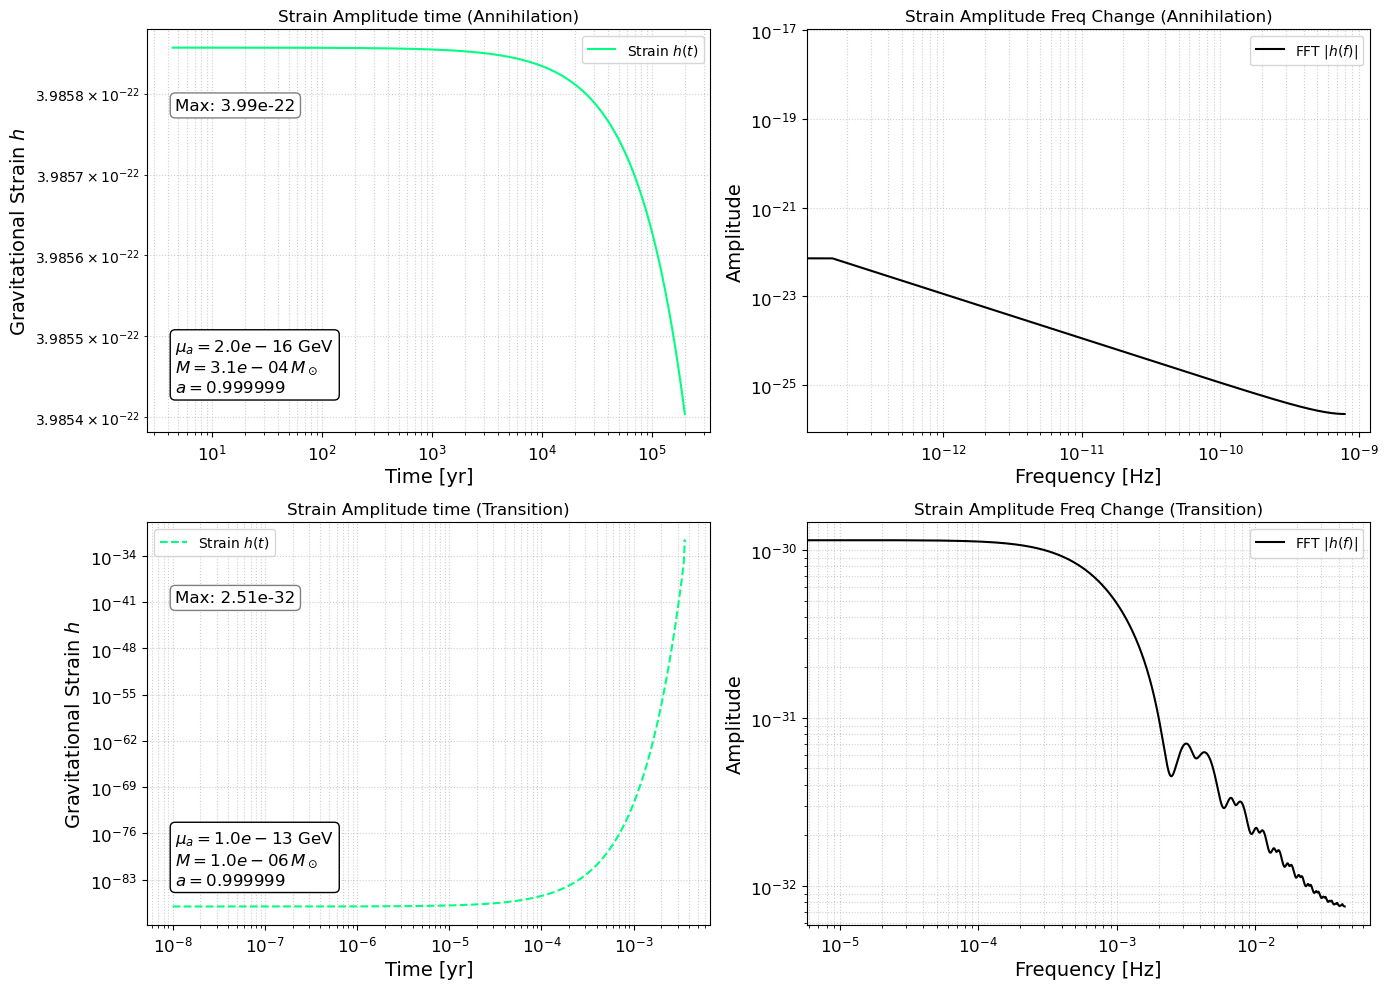

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from grav_atom_templates import simulate_axion_annihilation, simulate_two_level_evolution

# Parameters
M_ann = 3.1e-04  # in solar masses
mua_ann = 2e-16  # in GeV
a_ann = 0.999999

M_tr = 1e-06     # in solar masses
mua_tr = 1e-13   # in GeV
a_tr = 0.999999

# --- Run Annihilation Scenario ---
time_ann, N_ann, h_ann, freqs_ann, fft_ann = simulate_axion_annihilation(
    M_bh_solar_mass=M_ann,
    mua=mua_ann,
    a0=a_ann,
    d_kpc=1,
    n=4,
    l=3,
    m=3,
    num_steps=100000
)

# --- Run Two-Level Scenario ---
time_tr, N_exc, N_gnd, h_tr, nass_evol, spin_evol, freqs_tr, fft_tr = simulate_two_level_evolution(
    M_bh_solar_mass=M_tr,
    mua=mua_tr,
    a0=a_tr,
    dist_kpc=1,
    ne=6,
    ng=5,
    l=4,
    m=4,
    num_steps=10000
)




# === Plotting: Strain + FFT for Annihilation and Transition ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.winter(np.linspace(0, 1, 4))
fsize = 14

# --- Annihilation: Strain ---
axes[0, 0].plot(time_ann, np.abs(h_ann), color=colors[3], label='Strain $h(t)$')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Time [yr]', fontsize=fsize)
axes[0, 0].set_ylabel('Gravitational Strain $h$', fontsize=fsize)
axes[0, 0].set_title('Strain Amplitude time (Annihilation)')
axes[0, 0].legend()
max_h_ann = np.nanmax(h_ann)
axes[0, 0].text(0.05, 0.8, f'Max: {max_h_ann:.2e}', transform=axes[0, 0].transAxes,
                fontsize=12, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))
axes[0, 0].text(0.05, 0.1,
                f'$\\mu_a={mua_ann:.1e}$ GeV\n$M={M_ann:.1e}\\,M_\\odot$\n$a={a_ann:.6f}$',
                transform=axes[0, 0].transAxes,
                fontsize=12, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))

# --- Annihilation: FFT ---
axes[0, 1].plot(freqs_ann, np.abs(fft_ann), color='black', label='FFT $|h(f)|$')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Frequency [Hz]', fontsize=fsize)
axes[0, 1].set_ylabel('Amplitude', fontsize=fsize)
axes[0, 1].set_title('Strain Amplitude Freq Change (Annihilation)')
axes[0, 1].legend()

# --- Transition: Strain ---
axes[1, 0].plot(time_tr, h_tr, color=colors[3], linestyle='dashed', label='Strain $h(t)$')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Time [yr]', fontsize=fsize)
axes[1, 0].set_ylabel('Gravitational Strain $h$', fontsize=fsize)
axes[1, 0].set_title('Strain Amplitude time (Transition)')
axes[1, 0].legend()
max_h_tr = np.max(h_tr)
axes[1, 0].text(0.05, 0.8, f'Max: {max_h_tr:.2e}', transform=axes[1, 0].transAxes,
                fontsize=12, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))
axes[1, 0].text(0.05, 0.1,
                f'$\\mu_a={mua_tr:.1e}$ GeV\n$M={M_tr:.1e}\\,M_\\odot$\n$a={a_tr:.6f}$',
                transform=axes[1, 0].transAxes,
                fontsize=12, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))

# --- Transition: FFT ---
axes[1, 1].plot(freqs_tr, fft_tr, color='black', label='FFT $|h(f)|$')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel('Frequency [Hz]', fontsize=fsize)
axes[1, 1].set_ylabel('Amplitude', fontsize=fsize)
axes[1, 1].set_title('Strain Amplitude Freq Change (Transition)')
axes[1, 1].legend()



# Formatting
for ax in axes.flat:
    ax.grid(True, which='both', linestyle=':', alpha=0.6)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

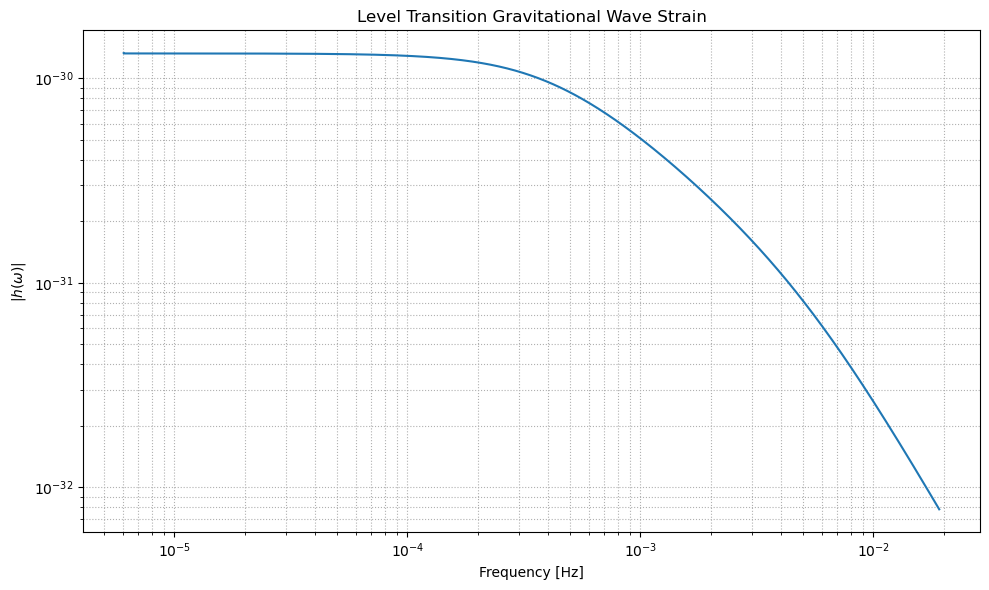

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
Mp = 1.220890e19
G = 1 / Mp**2           # Newton's G in GeV^-2
gev_to_hz = 6.582119569e-25 # GeV to Hz
M_sun = 1.989e30 * 5.61e26  # Solar mass in GeV
Mpc_to_Gev = 1.56e38        # 1 Mpc in GeV
kpc_to_Gev = Mpc_to_Gev / 1000
hbar_GeV = 6.582e-25 


# --- Level Transition Parameters ---
ne, ng = 6, 5
l = m = ng - 1
r_kpc = 1
r = r_kpc * kpc_to_Gev
M_tr = 1e-6 * M_sun
mu_a = 1e-13  # GeV
a_tr = 0.999999
alpha_tr = G * M_tr * mu_a
omega_plus = Omega_plus(a_tr, G*M_tr)

# --- Transition Frequency ---
omega_tr = 0.5 * mu_a * alpha_tr**2 * (1/ng**2 - 1/ne**2)

# --- Frequency Range (GeV) ---
omega = np.logspace(-29, -25.5, 10000)


gamma_e_vals = np.array([super_gamma(ne, l, m, w, mu_a, M_tr, r_plus(M_tr, a_tr), a_tr) for w in omega])
gamma_g_vals = np.array([super_gamma(ng, l, m, w, mu_a, M_tr, r_plus(M_tr, a_tr), a_tr) for w in omega])
# print(gamma_g_vals)
gamma_tr_val = gamma_t(ng, ne, mu_a, alpha_tr, M_tr)  # constant

T_vals = 2 / gamma_g_vals[0]  # Time scale (s) in GeV^-1
Ng = []
Ne = []
Ng0 = 0 
Ne0 = 0


for num, w in enumerate(omega):

    Ng0 = np.abs(N_g_omega(w, gamma_g_vals[num],gamma_tr_val, Ne0,T_vals))
    Ne0 = np.abs(N_g_omega(w, gamma_e_vals[num],gamma_tr_val, Ng0,T_vals))
    Ng.append(Ng0)
    Ne.append(Ne0)

Ne = np.array(Ne)
Ng = np.array(Ng)

# --- Compute strain ---
trans_strain = h_tr(r, omega_tr, gamma_e_vals, gamma_g_vals, gamma_tr_val, T_vals, omega,Ne,Ng)
trans_strain_abs = np.abs(trans_strain)*hbar_GeV

# --- Plot ---


f_hz_tr = omega / (np.sqrt(2*np.pi)* hbar_GeVs)


plt.figure(figsize=(10, 6))
plt.title('Level Transition Gravitational Wave Strain')
plt.plot(f_hz_tr, trans_strain_abs)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'$|h(\omega)|$')
plt.xscale('log')
plt.yscale('log')
# plt.xlim(1, 1e4)
# plt.ylim(1e-45, 1e-42)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# Level Transition Strain Annihilation Comparison 

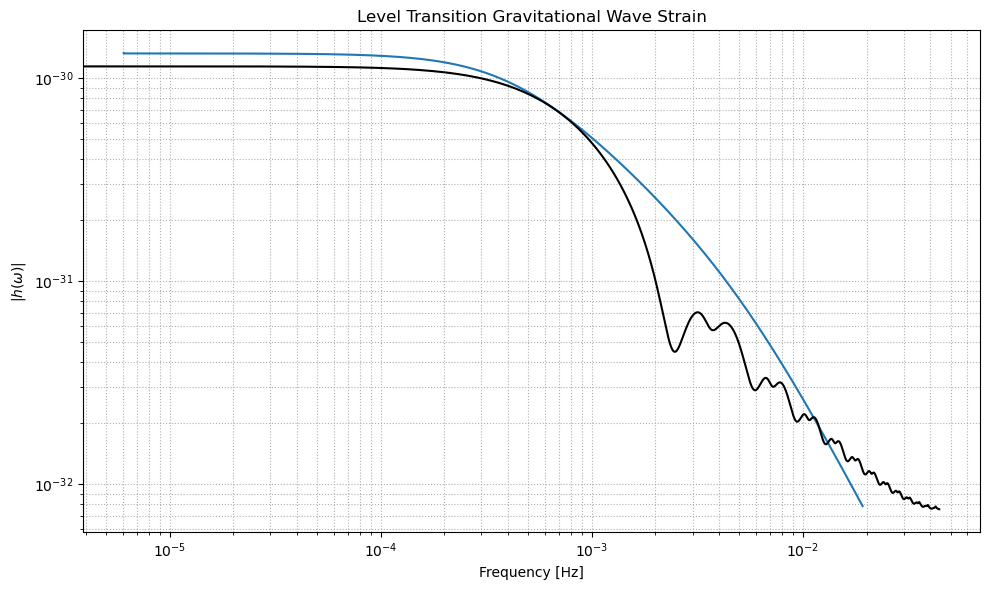

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Level Transition Gravitational Wave Strain')
plt.plot(f_hz_tr, trans_strain_abs)
plt.plot(freqs_tr, fft_tr, color='black', label='FFT $|h(f)|$')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'$|h(\omega)|$')
plt.xscale('log')
plt.yscale('log')
# plt.xlim(1, 1e4)
# plt.ylim(1e-45, 1e-42)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# Annihilation Frequency Domain Strain

In [ ]:
import numpy as np
import mpmath as mp


def _mp_ei_vec(z):
    return np.vectorize(lambda zz: complex(mp.ei(zz)))(z)

def h_ann(omega, N, Gamma_a, r, omega_ann):

    omega = np.asarray(omega, dtype=np.complex128)
    z = 1j * omega / (Gamma_a * N)  # argument for Ei and exponential
    
    pref = 1/(2*np.pi)*np.sqrt(4.0 * G  / (Gamma_a*r**2 * omega_ann))
    Ei = -2.0 * _mp_ei_vec(z) - np.log(-1j*omega) + np.log(1j*omega) + 1j * np.pi * np.sign(np.real(omega)) 

    return pref * np.exp(z) *Ei



3.9730733370262326e-16


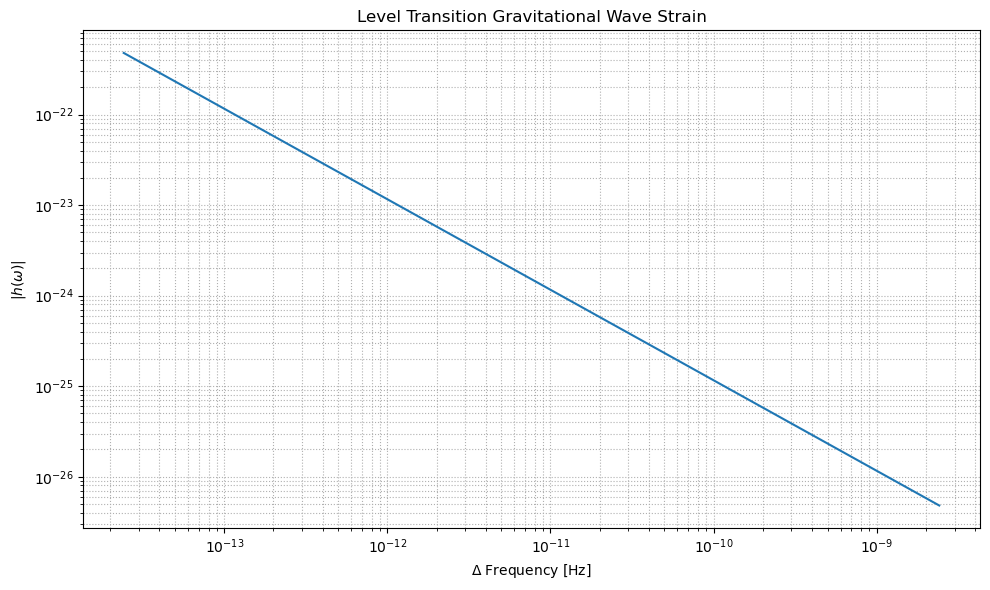

In [ ]:
# Dependent Params
M_ann = 3.1e-04  # in solar masses
max_N = N_max(M_ann)
M_ann = M_ann*M_sun # Solar masses in GeV
mua_ann = 2e-16  # in GeV
a_ann = 0.999999
alpha_ann = G*M_ann*mua_ann
r_kpc = 1
r = r_kpc * kpc_to_Gev
n = 4
m = l = n-1

# call functions
omega = np.logspace(-37, -32, 10000) # in GeV
omega_a = omega_ann(mua_ann, alpha_ann, n) # in GeV
print(omega_a)
gamma_ann = gamma_a(l, alpha_ann, M_ann) # in GeV

T_ann = 1/gamma_ann

ann_strain_abs = np.abs(h_ann(omega, max_N, gamma_ann, r, omega_a))*hbar_GeV
#frequency strain has units of h*Gev, need to convert to Hz and then divide by timescale of event (2e6) to match discrete fft


# convert to Hz for x-axis plots
omega_hza = omega / (2*np.pi*hbar_GeV)


plt.figure(figsize=(10, 6))
plt.title('Level Transition Gravitational Wave Strain')
plt.plot(omega_hza, ann_strain_abs)
plt.xlabel('$\Delta$ Frequency [Hz]')
plt.ylabel(r'$|h(\omega)|$')
plt.xscale('log')
plt.yscale('log')    
# plt.xlim(1, 1e4)
# plt.ylim(1e-45, 1e-42)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# Annihilation Strain Amplitude Comparison

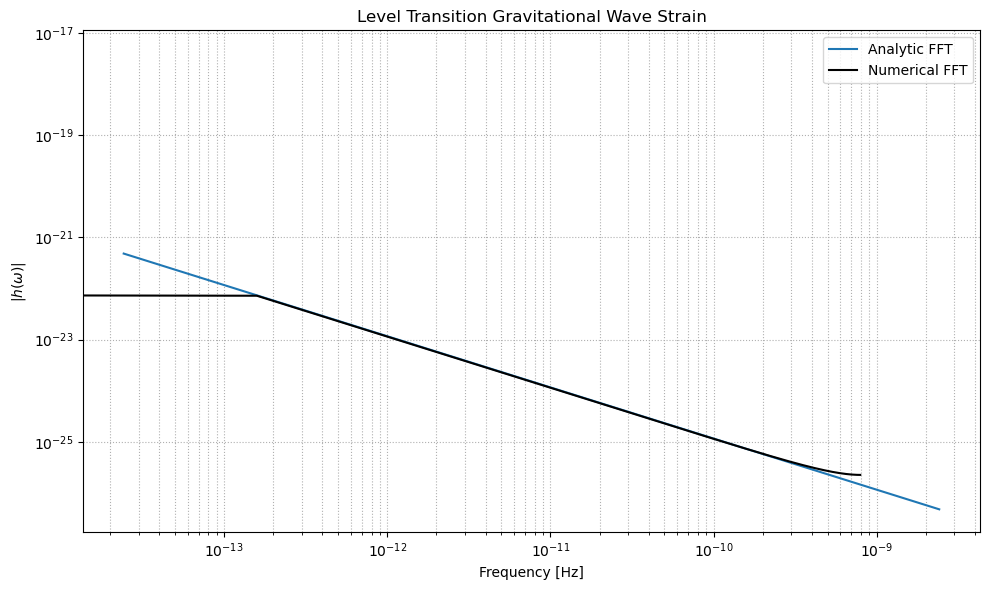

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Level Transition Gravitational Wave Strain')
plt.plot(omega_hza, ann_strain_abs, label = 'Analytic FFT')
plt.plot(freqs_ann, np.abs(fft_ann), color='black', label='Numerical FFT')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'$|h(\omega)|$')
plt.xscale('log')
plt.yscale('log')    

plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

# Numerical vs Analytic, all strains

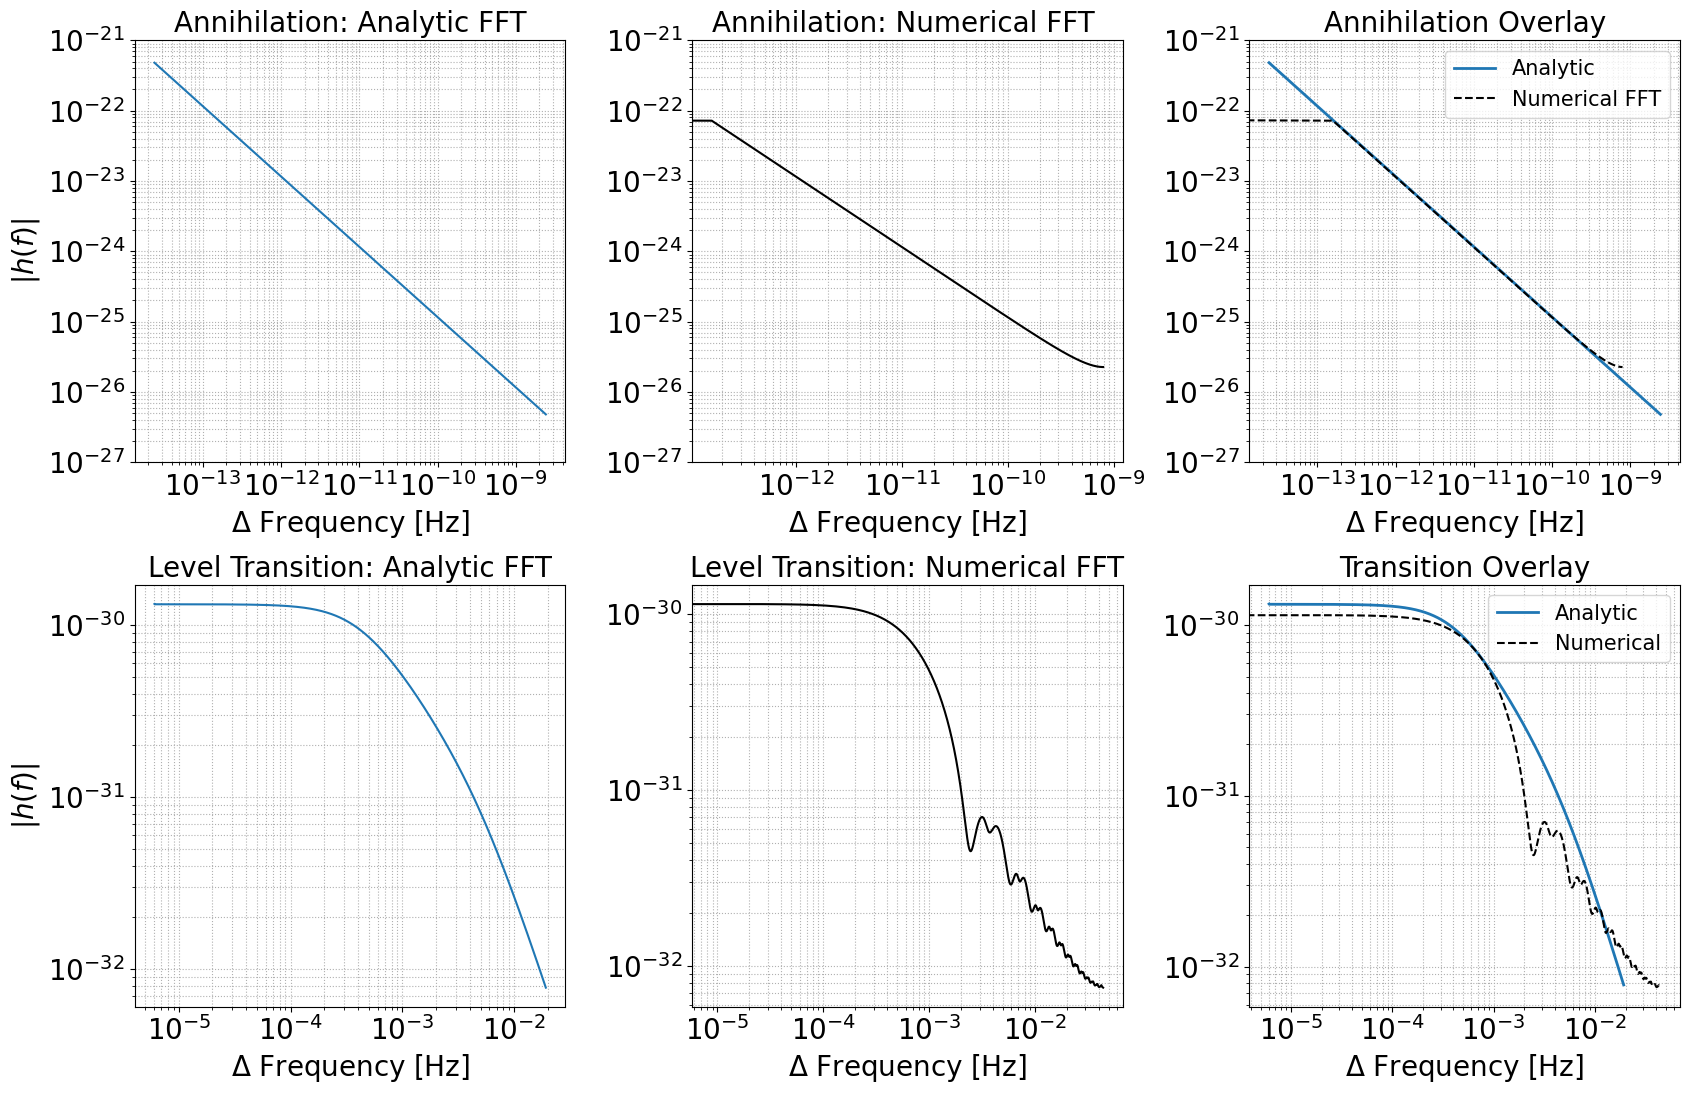

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Font size parameters
# --------------------------
title_fs = 20
label_fs = 20
tick_fs  = 20
legend_fs = 15

# --------------------------
# Plotting
# --------------------------

fig, axs = plt.subplots(2, 3, figsize=(17, 12))

# --- Row 1: Annihilation ---
# 1) Analytic annihilation
ax = axs[0, 0]
ax.plot(omega_hza, ann_strain_abs)
ax.set_title('Annihilation: Analytic FFT', fontsize=title_fs)
ax.set_xlabel('$\Delta$ Frequency [Hz]', fontsize=label_fs)
ax.set_ylabel(r'$|h(f)|$', fontsize=label_fs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-27, 1e-21)
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.grid(True, which='both', ls=':')

# 2) Numerical FFT annihilation
ax = axs[0, 1]
ax.plot(freqs_ann, np.abs(fft_ann), color='black')
ax.set_title('Annihilation: Numerical FFT ', fontsize=title_fs)
ax.set_xlabel('$\Delta$ Frequency [Hz]', fontsize=label_fs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-27, 1e-21)
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.grid(True, which='both', ls=':')

# 3) Overlay: analytic + numerical annihilation
ax = axs[0, 2]
ax.plot(omega_hza, ann_strain_abs, label='Analytic', lw=2)
ax.plot(freqs_ann, np.abs(fft_ann), color='black', ls='--', label='Numerical FFT')
ax.set_title('Annihilation Overlay', fontsize=title_fs)
ax.set_xlabel('$\Delta$ Frequency [Hz]', fontsize=label_fs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-27, 1e-21)
ax.legend(fontsize=legend_fs)
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.grid(True, which='both', ls=':')

# --- Row 2: Transition ---
# 4) Analytic transition
ax = axs[1, 0]
ax.plot(f_hz_tr, trans_strain_abs)
ax.set_title('Level Transition: Analytic FFT', fontsize=title_fs)
ax.set_xlabel('$\Delta$ Frequency [Hz]', fontsize=label_fs)
ax.set_ylabel(r'$|h(f)|$', fontsize=label_fs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.grid(True, which='both', ls=':')

# 5) Numerical FFT transition
ax = axs[1, 1]
ax.plot(freqs_tr, np.abs(fft_tr), color='black')
ax.set_title('Level Transition: Numerical FFT', fontsize=title_fs)
ax.set_xlabel('$\Delta$ Frequency [Hz]', fontsize=label_fs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.grid(True, which='both', ls=':')

# 6) Overlay: analytic + numerical transition
ax = axs[1, 2]
ax.plot(f_hz_tr, trans_strain_abs, label='Analytic', lw=2)
ax.plot(freqs_tr, np.abs(fft_tr), color='black', ls='--', label='Numerical')
ax.set_title('Transition Overlay', fontsize=title_fs)
ax.set_xlabel('$\Delta$ Frequency [Hz]', fontsize=label_fs)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=legend_fs)
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.grid(True, which='both', ls=':')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Both Strains on the same axis

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Constants ---
# Mp = 1.220890e19
# G = 1 / Mp**2           # Newton's G in GeV^-2
# gev_to_hz = 6.582119569e-25 # GeV to Hz
# M_sun = 1.989e30 * 5.61e26  # Solar mass in GeV
# Mpc_to_Gev = 1.56e38        # 1 Mpc in GeV
# kpc_to_Gev = Mpc_to_Gev / 1000
# hbar_GeV = 6.582e-25 


# #############################################################################################################################
# #                                               Transition Block                                                           `#
# #############################################################################################################################


# # --- Level Transition Parameters ---
# ne, ng = 6, 5
# l = m = ng - 1
# r_kpc = 1
# r = r_kpc * kpc_to_Gev
# M_tr = 1e-6 * M_sun
# mu_a = 1e-13  # GeV
# a_tr = 0.999999
# alpha_tr = G * M_tr * mu_a
# omega_plus = Omega_plus(a_tr, G*M_tr)

# # --- Transition Frequency ---
# omega_tr = 0.5 * mu_a * alpha_tr**2 * (1/ng**2 - 1/ne**2)

# # --- Frequency Range (GeV) ---
# omega = np.logspace(-36, -26, 10000)


# gamma_e_vals = np.array([super_gamma(ne, l, m, w, mu_a, M_tr, r_plus(M_tr, a_tr), a_tr) for w in omega])
# gamma_g_vals = np.array([super_gamma(ng, l, m, w, mu_a, M_tr, r_plus(M_tr, a_tr), a_tr) for w in omega])
# # print(gamma_g_vals)
# gamma_tr_val = gamma_t(ng, ne, mu_a, alpha_tr, M_tr)  # constant

# T_vals = 2 / gamma_g_vals[0]  # Time scale (s) in GeV^-1
# Ng = []
# Ne = []
# Ng0 = 0 



# for num, w in enumerate(omega):

#     Ng0 = np.abs(N_g_omega(w, gamma_g_vals[num],gamma_tr_val, Ne0,T_vals))
#     Ne0 = np.abs(N_g_omega(w, gamma_e_vals[num],gamma_tr_val, Ng0,T_vals))
#     Ng.append(Ng0)
#     Ne.append(Ne0)

# Ne = np.array(Ne)
# Ng = np.array(Ng)

# # --- Compute strain ---
# trans_strain = h_tr(r, omega_tr, gamma_e_vals, gamma_g_vals, gamma_tr_vals, T_vals, omega,Ne,Ng)
# trans_strain_abs = np.abs(trans_strain)*hbar_GeV

# # --- Plot ---


# f_hz = omega / (2 * np.pi * hbar_GeVs)



# #############################################################################################################################
# #                                               Annihilation Block                                                         `#
# #############################################################################################################################
# M_ann = 3.1e-04  # in solar masses
# max_N = N_max(M_ann)
# M_ann = M_ann*M_sun # Solar masses in GeV
# mua_ann = 2e-16  # in GeV
# a_ann = 0.999999
# alpha_ann = G*M_ann*mua_ann
# r_kpc = 1
# r = r_kpc * kpc_to_Gev
# n = 4
# m = l = n-1

# # call functions

# omega_a = omega_ann(mua_ann, alpha_ann, n) # in GeV
# gamma_ann = gamma_a(l, alpha_ann, M_ann) # in GeV
# print(gamma_ann)
# T_ann = 1/gamma_ann
# print(T_ann)

# ann_strain_abs = np.abs(h_ann(omega, max_N, gamma_ann, r, omega_a))*hbar_GeV
# #frequency strain has units of h*Gev, need to convert to Hz and then divide by timescale of event (2e6) to match discrete fft


# # convert to Hz for x-axis plots
# omega_hza = omega / gev_to_hz


# plt.figure(figsize=(10, 6))
# plt.title('Gravitational Wave Strain: Transition vs Annihilation')
# plt.plot(f_hz, trans_strain_abs, label='Transition')
# plt.plot(f_hz, ann_strain_abs, label='Annihilation')
# plt.xlabel('Frequency [Hz]')         # keeping your label text
# plt.ylabel(r'$|h(\omega)|$')
# plt.xscale('log')
# plt.yscale('log')
# plt.grid(True, which='both', ls=':')
# plt.legend()
# plt.tight_layout()
# plt.show()

# Reproducing Henrys Binary Perturbation Level Transition Strain

75209.4233977849
1e-05
7520942339.77849
[           nan 1.86298434e-28 1.91050929e-25 1.10428435e-23
 1.96720759e-22 1.83942889e-21 1.14437723e-20 5.37580522e-20
 2.05633807e-19 6.72464459e-19 1.94359262e-18 5.08391252e-18
 1.22475260e-17 2.75376376e-17 5.83871438e-17 1.17699224e-16
 2.27069790e-16 4.21517528e-16 7.56276701e-16 1.31636782e-15
 2.22985738e-15 3.68595682e-15 5.95939985e-15 9.44288570e-15
 1.46897927e-14 2.24698639e-14 3.38411560e-14 5.02422420e-14
 7.36094770e-14 1.06525104e-13 1.52403097e-13 2.15720970e-13
 3.02307275e-13 4.19696322e-13 5.77563671e-13 7.88258310e-13
 1.06745014e-12 1.43491454e-12 1.91547919e-12 2.54016273e-12
 3.34753891e-12 4.38536584e-12 5.71252520e-12 7.40132372e-12
 9.54021627e-12 1.22370190e-11 1.56226905e-11 1.98557697e-11
 2.51275723e-11 3.16682594e-11 3.97539110e-11 4.97147489e-11
 6.19446796e-11 7.69123416e-11 9.51738726e-11 1.17387633e-10
 1.44331158e-10 1.76920628e-10 2.16233216e-10 2.63532661e-10
 3.20298514e-10 3.88259510e-10 4.69431603e-10

C:\Users\24649\AppData\Local\Temp\ipykernel_18560\3152971405.py:313: RuntimeWarning: invalid value encountered in double_scalars
  delta1 = 0.5*(q/eps - eps - p*2j)*kappab_term*gam_terms
C:\Users\24649\AppData\Local\Temp\ipykernel_18560\3152971405.py:280: RuntimeWarning: invalid value encountered in cdouble_scalars
  return num/denom


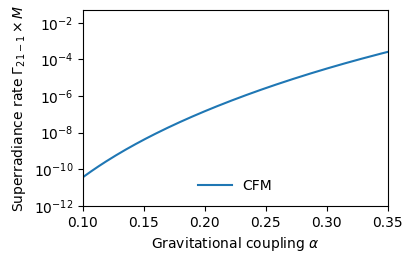

In [ ]:
import numpy as np
import math
from scipy.integrate import dblquad, quad
from scipy.special import sph_harm
from fractions import Fraction
from iminuit import Minuit
from math import factorial
#from numba import njit # Probably need to delete if converting into Julia, Julia does this already
from scipy.special import gamma

Mp = 1.220890e19
G = 1 / Mp**2 # THIS IS IN NATURAL UNITS

#-------------- Units conversions from BHSR-------------------------# TODO figure out the discrepancy between G and GNewton
eV_per_kg = 1.782622e-36
mP_in_GeV = 1.220890e19 # GeV
mP_in_eV = 1e9*mP_in_GeV # eV

# Astro constants
Msol_in_kg = 1.99841e30 # kg
Msol_in_eV = Msol_in_kg/eV_per_kg # eV

mP2_in_eVMsol = mP_in_eV*(mP_in_eV/Msol_in_eV) # eV Msol
GNewton = 1/mP2_in_eVMsol # Author of the BHSR code elected to let G have units of eV^-1 Msol^-1, instead of Gev^-2


#------------------End of Unit conversion---------------------#



#-----------------Beginning of Numerical Calculation of Eta------------------------------------------#
def eta_parameter(alpha, q, mass):
    """
    Numerically calculate the mixing amplitude for |211⟩ → |21-1⟩ transition
    
    Parameters:
    alpha: fine-structure constant
    q: mass ratio (M_companion / M)
    M: black hole mass in geometric units (seconds)
    
    
    Return:
    eta: adiabaticity parameter
    """
    
    #Parameters in natural units (ħ = c = 1)
    M = mass *2e30 * 5.61e26  # Black hole mass from solar to natural
        
    #Quantum numbers
    n = 2
    l_star, m_star = 2, -2 # for spherical harmonicis
    l_i, m_i = 1, 1 # for state transitions, initial state
    l_f, m_f = 1, -1 # for state transitions, final state
    Delta_m = np.abs(m_f-m_i) #Difference between mi and mf
    
    #Compute resonant orbital frequency Ω₀(In Planck Units)
    Omega0_binary_natural = (64 * m_i * alpha**7) / (G* M * n**3 * 2 * l_i * (2*l_i + 1) * (2*l_i + 2) * (m_i**2 + 4 * alpha**2))

    #Compute orbital frequency change rate γ(In Planck Units)
    gamma_rates = (96/5) * (q / (1+q)**(1/3)) * (G * M * Omega0_binary_natural)**(5/3) * Omega0_binary_natural**2
    
# Compute angular overlap integral I_A numerically
    def integrand(theta, phi):
        Y_star = sph_harm(m_star, l_star, phi, theta)
        Y_i = sph_harm(m_i, l_i, phi, theta)
        Y_f_conj = np.conj(sph_harm(m_f, l_f, phi, theta))
        return np.real(Y_star * Y_i * Y_f_conj * np.sin(theta))

    I_A, _ = dblquad(integrand, 0, 2*np.pi, 0, np.pi)
    
        #Compute Bohr radius and orbital separation
    r_c = G * M / alpha**2  # Bohr radius
    R_star = (G * M / Omega0_binary_natural**2)**(1/3)  # Orbital separation
    r_bar_max = R_star / r_c
    
    #Define radial wavefunction for |211⟩ state
    def R_21(r_bar):
        return (1/np.sqrt(24)) * r_bar * np.exp(-r_bar/2)
    
    #Compute radial overlaps I_in and I_out
    def integrand_in(r_bar):
        return (R_21(r_bar))**2 * r_bar**4
    
    def integrand_out(r_bar):
        return (R_21(r_bar))**2 / r_bar
    
    I_in, _ = quad(integrand_in, 0, r_bar_max)
    I_out, _ = quad(integrand_out, r_bar_max, np.inf)
    
    #Compute mixing amplitude η
    prefactor = np.sqrt(3*np.pi/10) * I_A
    term1 = (q * G*M * Omega0_binary_natural) / (alpha**3 * (1+q)) * I_in
    term2 = (alpha**7 * q * (1+q)**(2/3)) / (G*M*Omega0_binary_natural)**(7/3) * I_out
    eta = Omega0_binary_natural * np.abs(prefactor * (term1 + term2))
    return eta

#---------------End of Numerical Calculation of Eta------------------------------------------------------
def a_tilde_crit(m_i, alpha):
    m2 = m_i**2
    return (4.0 * m_i * alpha) / (m2 + 4.0 * alpha**2)


def q_c(alpha, m_i, a_tilde):

    m = float(m_i)
    one_minus = (1.0 - a_tilde / m)
    # guard small rounding errors inside the sqrt:
    inner = 1.0 - (4.0 * alpha / m * one_minus) ** 2
    inner = np.clip(inner, 0.0, 1.0)

    denom = m**2 * (1.0 - np.sqrt(inner))**2
    # Avoid divide-by-zero:
    if denom == 0.0:
        return 0.0

    return 8.0 * alpha**2 * one_minus / denom


# M is host BH mass
# Omega_0 is angular momentum at BH horizon

def h0_from_params(qc, M, r, alpha, Omega0):

    return 24.0 * G*(qc * M / r) * (alpha ** -4) * (G*M * Omega0) ** 2

#------------- Beginning of Relativitistic Gamma Rate from BHSR-------------------------



##----Alpha parameter from BHSR--------------

def rg(mbh: float) -> float:
    """
   Calculate the "gravitational radius" of a Kerr black hole

   Parameters:
      mbh (float): Black hole mass in Msol.

   Returns:
      float: The gravitational radius of the black hole in eV^-1.
   """
    return GNewton*mbh

def alpha(mu: float, mbh: float) -> float:
    """
   Compute the dimensionless coupling constant alpha.

   Parameters:
      mu (float): Boson mass in eV.
      mbh (float): Black hole mass in Msol.

   Returns:
      float: The dimensionless coupling constant alpha.
   """
    return rg(mbh)*mu

#@njit
def r_plus(mbh: float, astar: float) -> float:
    """
   Calculates the radius of the inner event horizon of a Kerr black hole.

   Parameters:
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.

   Returns:
      float: The radius of the inner event horizon in eV^-1.
   """
    return rg(mbh)*(1 + np.sqrt(1 - astar*astar))


##-----------------omegaHyperfine from BHSR-----------------##

def omegaHyperfine(mu: float, mbh: float, astar: float, n: int, l: int, m: int) -> float:
    """
   Calculates the  hyperfine frequency of the superradiant mode for a given set of quantum numbers quantum numbers |n,l,m>.

   Parameters:
      mu (float): Boson mass in eV.
      mbh (float): Black hole mass in Msol.
      n (int): Principal quantum number.
      l (int): Orbital angular momentum quantum number (currently not used).
      m (int): Magnetic quantum number (currently not used).

   Returns:
      float: The frequency of the superradiant mode in eV.

   Notes:
      - See Eq. (2.28) in https://arxiv.org/pdf/1908.10370.pdf
    """
    x = alpha(mu, mbh)/n
    x2 = x*x
    x4 = x2*x2
    fine = 1.875 - 6.0*n/(2*l+1) # = 2 - 1/8 - ...
    hyperfine = 8.0*m*n*n*astar/(l*(2*l+1)*(2*l+2))
    return mu*(1.0 - 0.5*x2 + fine*x4 + hyperfine*x*x4)

##-------

## BHSR rates using higher-order corrections

#@njit("float64(float64, float64, uint8)")
def omega0_bxzh(mu: float, mbh: float, n: int) -> float:
    """
   Helper function to compute the leading-order (LO) frequency of the superradiant mode.

   Parameters:
      mu (float): Boson mass in eV.
      mbh (float): Black hole mass in Msol.
      n (int): Principal quantum number.

   Returns:
      float: Contribution to the LO frequency of the superradiant mode in eV.

   Notes:
      - See Eq. (16a) in https://arxiv.org/pdf/2201.10941.pdf
   """
    n2 = n*n
    al = alpha(mu, mbh)
    al2 = al*al
    x = 2*al2/(n2 + 4*al2 + n*np.sqrt(n2 + 8*al2))
    return mu*np.sqrt(1.0 - x)

#@njit("float64(float64, float64, uint8)")
def omega1_bxzh(mu: float, mbh: float, n: int) -> float:
    """
   Helper function to compute the leading-order (LO) frequency of the superradiant mode.

   Parameters:
      mu (float): Boson mass in eV.
      mbh (float): Black hole mass in Msol.
      n (int): Principal quantum number.

   Returns:
      float: Contribution to the LO frequency of the superradiant mode in eV.

   Notes:
      - See Eq. (16b) in https://arxiv.org/pdf/2201.10941.pdf
   """
    om0 = omega0_bxzh(mu, mbh, n)
    if om0 > 0:
        om02 = om0*om0
        mu2 = mu*mu
        al = alpha(mu, mbh)
        al2 = al*al
        x = 1.0 + 4*al2*(2*om02/mu2 - 1.0)/(n*n)
        return (mu2 - om02)/(n*om0*x)
    return 0

def gam_pq_bxzh(p: float, q: float, eps: float, n: int, l: int) -> float:
    """
   Helper function to compute the next-to-leading-order (NLO) energy level of the superradiant mode.

   Parameters:
      p (float): Parameter p.
      q (float): Parameter q.
      eps (float): Parameter epsilon.
      n (int): Principal quantum number.
      l (int): Orbital angular momentum quantum number.

   Returns:
      float: Dimensionless facotor.

   Notes:
      - See Eqs. (22, 23) in https://arxiv.org/pdf/2201.10941.pdf
    """
    lp = l + eps
    ip = p*1j
    twolp = 2*lp
    g1 = gamma(twolp + 1) 
    g2 = gamma(twolp + 2)
    g2n = gamma(twolp + 1 + n - l)
    gpmeps = gamma(1 + 2*eps)*gamma(1 - 2*eps)
    x1 = lp + 1 + ip
    x2 = np.sqrt(q - p*p + 0j)
    gabs = np.abs(gamma(x1 + x2)*gamma(x1 - x2))
    gmix = gamma(1.0 - ip - eps + x2)*gamma(1.0 - ip - eps - x2)
    gmix *= gamma(1.0 + ip + eps + x2)*gamma(1.0 + ip + eps - x2)
    num = g2n*gpmeps*gabs*gabs*pow(2, 4*lp + 2)
    denom = factorial(n-l-1)*g1*g1*g2*g2*gmix 
    return num/denom

def omega_nlm_bxzh(mu: float, mbh: float, astar: float, n: int = 2, l: int = 1, m: int = 1) -> tuple[float, float]:
    """
   Compute the complex valued frequency of the superradiant mode for the |n,l,m> state, following https://arxiv.org/pdf/2201.10941.pdf.

   Parameters:
      mu (float): Boson mass in eV.
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.
      n (int, optional): Principal quantum number (default: n = 2).
      l (int, optional): Orbital angular momentum quantum number (default: l = 1)
      m (int, optional): Magnetic quantum number (default: m = 1)

   Returns:
      tuple[float, float]: Real and imaginary parts of the frequency in eV.
    """
    om0 = omega0_bxzh(mu, mbh, n)
    om1 = omega1_bxzh(mu, mbh, n)
    al = alpha(mu, mbh)
    al2 = al*al
    eps = -8.0*al2/(2*l+1)
    lp = l + eps
    if lp < 0:
        return 0, 0
    rp = r_plus(mbh, astar)
    rG = rg(mbh)
    x = np.sqrt(1.0 - astar*astar)
    y = mu*mu - om0*om0
    p = -0.5*(m*astar - 2.0*rp*om0)/x
    q = 4*om0*p*rG - 2*(3.0 - x)*al2
    gam_terms = gam_pq_bxzh(p, q, eps, n, l)
    kappab_term = pow(rG*rG*x*x*y, lp+0.5)
    delta1 = 0.5*(q/eps - eps - p*2j)*kappab_term*gam_terms
    om = om0 + (eps + delta1)*om1
    return om.real, om.imag
#--------------------------------------below is to get function "root_equation" working--------------------#


#@njit("float64(uint8, int16, uint8)")
def h_seidel(l: int, m: int = 1, s: int = 0) -> float:
    """
   Helper function for alm_approx.

   Parameters:
      l (int): Orbital angular momentum quantum number.
      m (int, optional): Azimuthal quantum number (default: 1).
      s (int, optional): Spin of the boson (default: 0).

   Returns:
      float: The \f$h(l)\f$ function.

   Notes:
      - Eq. (8) in https://doi.org/10.1088/0264-9381/6/7/012
   """
    num = l*(l*l - m*m)
    denom = 2*(l-0.5)*(l+0.5)
    if s > 0:
        mabs = np.abs(m)
        s1 = max(mabs, s)
        s2 = m*s/max(mabs, s)
        l2 = l*l
        num = (l2 - s1*s1)*(l2 - s*s)*(l2 - s2*s2)
        denom *= l2*l
    return num/denom

#@njit("float64(uint8, int16, uint8)")
def flm_seidel_2(l: int, m: int = 1, s: int = 0) -> float:
    """
   Helper function for alm_approx.

   Parameters:
      l (int): Orbital angular momentum quantum number.
      m (int, optional): Azimuthal quantum number (default: 1).
      s (int, optional): Spin of the boson (default: 0).

   Returns:
      float: The \f$_sf_2^{lm}\f$ contribution.

   Notes:
      - Eq. (10c) in https://doi.org/10.1088/0264-9381/6/7/012
   """
    return h_seidel(l+1, m, s) - h_seidel(l, m, s) - 1

#@njit("float64(uint8, int16, uint8)")
def flm_seidel_4(l: int, m: int = 1, s: int = 0) -> float:
    """
   Helper function for alm_approx.

   Parameters:
      l (int): Orbital angular momentum quantum number.
      m (int, optional): Azimuthal quantum number (default: 1).
      s (int, optional): Spin of the boson (default: 0).

   Returns:
      float: The \f$_sf_4^{lm}\f$ contribution.

   Notes:
      - Eq. (10e) in https://doi.org/10.1088/0264-9381/6/7/012
   """
    hl = h_seidel(l, m, s)
    hlp1 = h_seidel(l+1, m, s)
    hlp2 = h_seidel(l+2, m, s)
    twol = 2*l
    l2 = l*l
    lm1 = l-1
    lp1 = l+1
    lp2 = l+2
    res = (hlp1 - lp2*hlp2/(twol+3))*hlp1/(2*lp1)
    res += (hlp1/lp1 - hl)*hl/twol
    res += lm1*h_seidel(l-1, m, s)*hl/(twol*(twol-1))
    if s > 0:
        lp2sq = lp2*lp2
        lm1sq = lm1*lm1
        lp1sq = lp1*lp1
        res += 4*( hlp1/(lp1sq*lp2sq) - hl/(l2*lm1sq))*m*m*pow(s,4)/(l2*lp1sq)
    return res

#@njit("complex128(complex128, uint8, int16, uint8)")
def alm_approx(c: complex , l: int, m: int = 1, s: int = 0) -> complex:
    """
   The eigenvalues \f$A_{lm}\f$ of the spin-weighted spheroidal(!) functions.

   Parameters:
      l (int): Orbital angular momentum quantum number.
      m (int, optional): Azimuthal quantum number (default: 1).
      s (int, optional): Spin of the boson (default: 0).

   Returns:
      float: The \f$A_{lm}\f$ eigenvalues.

   Notes:
      - Eq. (7) in https://doi.org/10.1088/0264-9381/6/7/012 with \f$A_{lm} \equiv _sE_l^m - s(s+1)\f$.
   """
    fvals = [l*(l+1), flm_seidel_2(l, m, s), flm_seidel_4(l, m, s)]
    expansion = [f*pow(c,2*i) for i,f in enumerate(fvals)]
    return sum(expansion)

# Compute continued fraction based on arXiv:0705.2880 # Probably need to delete every njit when converting into Julia

#@njit(cache=True)
def _calF(s, l, m):
    """ Eq. (52b) """

    if ((0==s) and (0 == l+1)):
        # This can only happen when solving for the mode labeled by s=0, l=0, m=0
        return 0.

    return (np.sqrt( ((l+1)**2 - m*m) / (2*l+3) / (2*l+1) )
            * np.sqrt( ( (l+1)**2  - s*s)  / (l+1)**2 ))

#@njit(cache=True)
def _calG(s, l, m):
    """ Eq. (52c) """
    if (0 == l):
        return 0.

    return np.sqrt( ( l*l - m*m ) / (4*l*l - 1)) * np.sqrt(1 - s*s/l/l)

#@njit(cache=True)
def _calH(s, l, m):
    """ Eq. (52d) """
    if (0 == l) or (0 == s):
        return 0.

    return - m*s/l/(l+1)

#@njit(cache=True)
def _calA(s, l, m):
    """ Eq. (53a) """
    return _calF(s,l,m) * _calF(s,l+1,m)

#@njit(cache=True)
def _calD(s, l, m):
    """ Eq. (53b) """
    return _calF(s,l,m) * (_calH(s,l+1,m)  + _calH(s,l,m))

#@njit(cache=True)
def _calB(s, l, m):
    """ Eq. (53c) """
    return (_calF(s,l,m) * _calG(s,l+1,m)
            + _calG(s,l,m) * _calF(s,l-1,m)
            + _calH(s,l,m)**2)

#@njit(cache=True)
def _calE(s, l, m):
    """ Eq. (53d) """
    return _calG(s,l,m) * (_calH(s,l-1,m) + _calH(s,l,m))

#@njit(cache=True)
def _calC(s, l, m):
    """ Eq. (53e) """
    return _calG(s,l,m) * _calG(s,l-1,m)

#@njit(cache=True)
def swsphericalh_A(s, l, m):
    """ Angular separation constant at a=0.

    Eq. (50). Has no dependence on m. The formula is
      A_0 = l(l+1) - s(s+1)

    Parameters
    ----------
    s: int
      Spin-weight of interest

    l: int
      Angular quantum number of interest

    m: int
      Magnetic quantum number, ignored

    Returns
    -------
    int
      Value of A(a=0) = l(l+1) - s(s+1)
    """

    return l*(l+1) - s*(s+1)

#@njit(cache=True)
def M_matrix_elem(s, c, m, l, lprime):
    """ The (l, lprime) matrix element from the spherical-spheroidal
    decomposition matrix from Eq. (55).

    Parameters
    ----------
    s: int
      Spin-weight of interest

    c: complex
      Oblateness of the spheroidal harmonic

    m: int
      Magnetic quantum number

    l: int
      Angular quantum number of interest

    lprime: int
      Primed quantum number of interest

    Returns
    -------
    complex
      Matrix element M_{l, lprime}
    """

    if (lprime == l-2):
        return -c*c*_calA(s,lprime,m)
    if (lprime == l-1):
        return (-c*c*_calD(s,lprime,m)
                + 2*c*s*_calF(s,lprime,m))
    if (lprime == l  ):
        return (swsphericalh_A(s,lprime,m)
                - c*c*_calB(s,lprime,m)
                + 2*c*s*_calH(s,lprime,m))
    if (lprime == l+1):
        return (-c*c*_calE(s,lprime,m)
                + 2*c*s*_calG(s,lprime,m))
    if (lprime == l+2):
        return -c*c*_calC(s,lprime,m)

    return 0.

def l_min(s, m):
    """ Minimum allowed value of l for a given s, m.

    The formula is l_min = max(\|m\|,\|s\|).

    Parameters
    ----------
    s: int
      Spin-weight of interest

    m: int
      Magnetic quantum number

    Returns
    -------
    int
      l_min
    """

    return max(abs(s), abs(m))

#@njit(cache=True)
def ells(s, m, l_max):
    """Vector of ℓ values in C vector and M matrix.

    The format of the C vector and M matrix is that the 0th element
    corresponds to l_min(s,m) (see :meth:`l_min`).

    Parameters
    ----------
    s: int
      Spin-weight of interest

    m: int
      Magnetic quantum number

    l_max: int
      Maximum angular quantum number

    Returns
    -------
    int ndarray
      Vector of ℓ values, starting from l_min
    """

    return np.arange(l_min(s,m), l_max+1)



#@njit(cache=True)
def M_matrix(s, c, m, l_max): # Seems to be a Julia Package for this by the same author, GitHub: https://github.com/duetosymmetry/SpinWeightedSpheroidalHarmonics.jl
    """Spherical-spheroidal decomposition matrix truncated at l_max.

    Parameters
    ----------
    s: int
      Spin-weight of interest

    c: complex
      Oblateness of the spheroidal harmonic

    m: int
      Magnetic quantum number

    l_max: int
      Maximum angular quantum number

    Returns
    -------
    complex ndarray
      Decomposition matrix
    """

    _ells = ells(s, m, l_max)

    M = np.empty((len(_ells),len(_ells)), dtype=np.complex128) #len is length in Julia

    for i in range(len(_ells)):
        for j in range(len(_ells)):
            M[i,j] = M_matrix_elem(s, c, m, _ells[i], _ells[j])

    return M

def sep_consts(s, c, m, l_max):
    """Finds eigenvalues of decomposition matrix, i.e. the separation
    constants, As.

    Parameters
    ----------
    s: int
      Spin-weight of interest

    c: complex
      Oblateness of spheroidal harmonic

    m: int
      Magnetic quantum number

    l_max: int
      Maximum angular quantum number

    Returns
    -------
    complex ndarray
      Eigenvalues of spherical-spheroidal decomposition matrix
    """

    return np.linalg.eigvals(M_matrix(s, c, m, l_max))


def angular_ev(omega: complex, mbh: float, astar: float, mu: float, l: int, m: int) -> complex:
    """
   Compute the angular eigenvalue of the spin-weighted spheroidal(!) functions.

   Parameters:
      omega (complex): The frequency of the perturbation in eV.
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.
      mu (float): Boson mass in eV.
      l (int): Orbital angular momentum quantum number.
      m (int): Azimuthal quantum number.

   Returns:
      complex: The angular eigenvalue of the spin-weighted spheroidal(!) functions.
   """
    c = rg(mbh)*astar*np.sqrt(omega*omega - mu*mu)
    if np.abs(c) > 3:
      # Need to use the 'qnm' package here
      # print("WARNING. |c| > 3 detected. Use qlm.")
        return np.sort(sep_consts(s=0, c=c, m=m, l_max=l))[-1]
    return alm_approx(c, l, m, s=0)

#@njit("UniTuple(complex128, 7)(complex128, float64, float64, float64, complex128, uint8)")
def cfunctions(omega: complex, mbh: float, astar: float, mu: float, alm: complex, m: int) -> tuple[complex, ...]:
    """
   Computes numerical coefficients for the continued fraction method.

   Parameters:
      omega (complex): The frequency of the perturbation in eV.
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.
      mu (float): Boson mass in eV.
      alm (complex): The eigenvalue of the angular equation \f$\mathcal{A}_{nlm}\f$.
      m (int): Azimuthal quantum number.
   
   Returns:
      tuple[complex]: The numerical coefficients for the continued fraction method.
   
   Notes:
      - Eqs (40)-44 in https://arxiv.org/pdf/0705.2880.pdf
      - The \f$\mathcal{A}_{nlm}\f$ should be computed using the `angular_ev` function to allow for optimisation with numba.
   """
    a = astar
    a2 = a*a
    b = np.sqrt(1 - a2)
    om = rg(mbh)*omega
    om2 = om*om
    mu_r = rg(mbh)*mu
    mu2 = mu_r*mu_r
   # Choose appropriate sign for bound states
    q = np.sqrt(mu2 - om2)
   # cN2 = 0.75 + (2*(b+1)*om2 - (2*b+1)*mu2)/q
    q = -np.sign(q.real)*q
    cN1 = 4*b*q
    cN2 = 0.75 + (2*(b+1)*om2 - (2*b+1)*mu2)/q
    q2 = q*q
    x = (om - 0.5*m*a)/b
    y = 2j*(om + x)
    z = om - 1j*q
    z2 = z*z/q
   # Compute the numerical coefficients
    c0 = 1 - y
    c1 = -4 + 2*y + 4*(b + 1)*q - 2*(q2 + om2)/q
    c2 = 3 - y - 2*(q2 - om2)/q
    c3 = 2j*z*z2 + a2*q2 + 2j*m*a*q + (z2 + 1)*(2j*x + 2*b*q - 1) - alm
    c4 = z2*z2 + 2j*z2*(om - x)
    return c0, c1, c2, c3, c4, cN1, cN2

#@njit("complex128(uint8, complex128)")
def alpha_n(n: int, c0: complex) -> complex:
    """
   The \f$\alpha_n\f$ coefficients in the continued fraction.

   Parameters:
      n (int): The index of the coefficient.
      d0 (complex): The \f$c_0\f$ coefficient.

   Returns:
      complex: The \f$\alpha_n\f$ coefficient.

   Notes:
      - Eq. (37) in https://arxiv.org/pdf/0705.2880.pdf
   """
    return n*n + (c0 + 1)*n + c0

#"("complex128(uint8, complex128, complex128)")"
def beta_n(n: int, d1: complex, d3: complex) -> complex:
    """
   The \f$\beta_n\f$ coefficients in the continued fraction.

   Parameters:
      n (int): The index of the coefficient.
      d1 (complex): The \f$c_1\f$ coefficient.
      d3 (complex): The \f$c_3\f$ coefficient.

   Returns:
      complex: The \f$\beta_n\f$ coefficient.

   Notes:
      - Eq. (38) in https://arxiv.org/pdf/0705.2880.pdf
   """
    return -2*n*n + (d1 + 2)*n + d3

#"("complex128(uint8, complex128, complex128)")"
def gamma_n(n: int, c2: complex, c4: complex) -> complex:
    """
   The \f$\gamma_n\f$ coefficients in the continued fraction.

   Parameters:
      n (int): The index of the coefficient.
      c2 (complex): The \f$c_2\f$ coefficient.
      c4 (complex): The \f$c_4\f$ coefficient.

   Returns:
      complex: The \f$\gamma_n\f$ coefficient.

   Notes:
      - Eq. (39) in https://arxiv.org/pdf/0705.2880.pdf
   """ 
    return n*n + (c2 - 3)*n + c4


def continued_fraction(omega: complex, mbh: float, astar: float, mu: float, alm: complex, m: int, nmax: int = 2000) -> complex:
    """
   Compute the continued fraction equation, whose complex roots are the frequencies.

   Parameters:
      omega (complex): The frequency of the perturbation in eV.
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.
      mu (float): Boson mass in eV.
      alm (complex): The eigenvalue of the angular equation \f$\mathcal{A}_{nlm}\f$.
      m (int): Azimuthal quantum number.
      nmax (int, optional): The maximum number of iterations (default: 2000).
   
   Returns:
      complex: The value of the continued fraction equation.

   Notes:
      - Eq. (48) in https://arxiv.org/pdf/0705.2880.pdf
      - We set the residual terms \f$f_N\f$ to zero; see Sec. II C in https://arxiv.org/pdf/1410.7698.pdf for alternatives.
   """
    c0, c1, c2, c3, c4, cN1, cN2 = cfunctions(omega, mbh, astar, mu, alm, m)
    fr = (-1+0j) + cN1/np.sqrt(nmax) + cN2/nmax # Improved residual term
    fr0 = beta_n(0, c1, c3)/alpha_n(0, c0)
    flipped_range = [nmax-i for i in range(nmax)]
    for i in flipped_range:
        alph = alpha_n(i, c0)
        beta = beta_n(i, c1, c3)
        gam = gamma_n(i, c2, c4)
        fr = gam/(beta - alph*fr)
    return fr0/fr - 1

def root_equation(omega: complex, mbh: float, astar: float, mu: float, l: int, m: int) -> float:
    """
   Helper function for the root equation

   Parameters:
      omega (complex): The frequency of the perturbation in eV.
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.
      mu (float): Boson mass in eV.
      l (int): Orbital angular momentum quantum number.
      m (int): Azimuthal quantum number.
   
   Returns:
      float: The value of the root equation.
   
   Notes:
      - This wrapper allows continued_fraction(...) to be optimised with numba.
    """
    alm = angular_ev(omega, mbh, astar, mu, l, m)
    z = continued_fraction(omega, mbh, astar, mu, alm, m)
    return np.log(z+1)


##--------The Root finding function----------------##

def find_cf_root(mbh: float, astar: float, mu: float, n: int = 2, l: int = 1, m: int = 1, verbose: bool = False) -> complex:
   
    """
   Root-finding algorithm for the continued fraction method.
   
   Parameters:
      mbh (float): Black hole mass in Msol.
      astar (float): Dimensionless black hole spin parameter.
      mu (float): Boson mass in eV.
      n (int, optional): Principal quantum number (default: n = 2).
      l (int, optional): Orbital angular momentum quantum number (default: l = 1)
      m (int, optional): Magnetic quantum number (default: m = 1)
      verbose (bool, optional): Print additional information (default: False).

   Returns:
      complex: Complex frequency of the level in eV.
   """
    alph = alpha(mu, mbh) # need this DONE
    omR = omegaHyperfine(mu, mbh, astar, n, l, m) 
    _, omI = omega_nlm_bxzh(mu, mbh, astar, n, l, m) 
    if omR > 0 and omI > 0 and alph > 0:
        cost_oR = lambda x: np.log(np.abs(root_equation(x+1j*omI, mbh, astar, mu, l, m))) #cost function for optimization that's used to find the real part of the complex frequency
        mR = Minuit(cost_oR, x=omR) #There should be a Minuit Package in Julia
        mR.tol = 1e-10
        factor = 0.5*alph*alph
        om0 = mu*(1 - 0.5*factor*( 1.0/((n-1)*(n-1)) + 1.0/(n*n) ))
        om1 = mu*(1 - factor/(n*n))
        mR.limits["x"] = (om0, om1)
        mR.migrad()
        cost = lambda x, lgy: np.abs(root_equation(x+1j*pow(10,lgy), mbh, astar, mu, l, m))
        mRI = Minuit(cost, x=mR.values["x"], lgy=np.log10(omI))
        mRI.tol = 1e-10
        mRI.limits["x"] = (om0, om1)
        mRI.limits["lgy"] = (np.log10(0.7*omI), min(np.log10(10*omI), np.log10(0.1*omR)))
        mRI.migrad()
        om = mRI.values["x"] + 1j*pow(10, mRI.values["lgy"])
    else:
        if verbose:
            print("Estimates for real or imaginary part of omega are not positive:", om)
        return omR + 1j*omI
    return om




##---------------------SR Gamma Calculation------------------------------##



# Initialise the model and example parameters
#bc0 = ub.UltralightBoson(spin=0, model="relativistic")# THIS SEEMS NOT USED?
#alphaval=0.3 #benchmark parameter of Antonios paper 
# Define astar0 as a function of alpha


mbh0 = 10**(-5) # Black hole mass, Msolar

# Define the range of boson masses/alpha values to consider
mu_max = 6.67944*10**(-6)
muvals = np.linspace(0, mu_max, 250)
alphvals = alpha(muvals, mbh0)
astar0_vals = (4*alphvals) / (1 + (4*alphvals**2))
#muvals_small = np.linspace(1e-13, mu_max, 100)
#alphvals_small = alpha(muvals_small, mbh0)

# Compute the SR rates
roots = [
    find_cf_root(mbh0, astar, mu, 2, 1, -1) 
    for mu, astar in zip(muvals, astar0_vals)
]

cfm_bhsr_rates = np.abs(np.array([z.imag for z in roots])*rg(mbh0)) # CFM SR rates, this provides SR rates for
#each alpha value within alphvals
print(rg(mbh0))
print(mbh0)
print(GNewton)
print(cfm_bhsr_rates)

#Plot the SR rate vs alpha values
fig, ax = plt.subplots(figsize=(4, 2.5))

p3 = ax.plot(alphvals, cfm_bhsr_rates, ls='-', label=r"CFM")
#p5 = ax.plot(alphvals, superrad_bhsr_rates, ls=':', label=r"\textsc{SuperRad}")
#p1 = ax.plot(alphvals, nr_bhsr_rates, ls='-.', label=r"NRA")
#p2 = ax.plot(alphvals, ho_bhsr_rates, ls='--', label=r"NLO")


ax.legend(frameon=False, handlelength=2.4, loc=8)
ax.set_xlabel(r"Gravitational coupling $\alpha$")
ax.set_ylabel(r"Superradiance rate $\Gamma_{21-1} \times M$")
ax.set_xlim([0.1, 0.35])
ax.set_ylim([1e-12, 0.5e-1])
ax.set_yscale('log')
fig.tight_layout(pad=0.25)

plt.show()


#------------- End of Relativitistic Gamma Rate from BHSR-------------------------

#------------------------------------------------------------------

def gamma_rate(q, M, Omega0):
    return (Omega0**2) * (96.0 / 5.0) * (q / (q + 1.0) ** (1.0 / 3.0)) * (M * Omega0) ** (5.0 / 3.0)



def z_parameter(eta, Delta_m, gamma):
    return (eta ** 2) / (abs(Delta_m) * gamma)


def z_scaling_211_to_21m1(alpha, q):
    """
    z_{211->21-1} ≈ 7 * (1.81/(1+4 α^2))^(1/3) * (q)^(1/3) * (2/(1+q))^(5/3) * (0.45/α)^(11/3)
    """
    return 7.0 * (1.81 / (1.0 + 4.0 * alpha**2)) ** (1.0 / 3.0) \
             * (q ** (1.0 / 3.0)) \
             * (2.0 / (1.0 + q)) ** (5.0 / 3.0) \
             * (0.45 / alpha) ** (11.0 / 3.0)



def fc_from_Omega0(Omega0):
    return (2.0 / np.pi) * Omega0*1e23

def psi_plus(f, r, f0, Delta_m, gamma):
    return f * r + (f - f0) ** 2 / (4.0 * abs(Delta_m) * gamma) - np.pi / 4.0



def htilde_plus(
    f,                     # array-like (Hz in your chosen units)
    M, r, alpha,           # source mass, distance, fine-structure parameter
    Omega0,                # orbital frequency scale
    q,                     # binary mass ratio (companion/host)
    m_i, m_f,              # initial/final magnetic quantum numbers (e.g., 1 -> -1)
    eta,                   # parameter entering z (or leave None to use z_scaling below)
    Gamma_abs,             # |Γ| > 0 (same units as f)
    use_z_scaling=False    # if True, use Eq. (15.5) instead of z=η^2/(|Δm|γ)
):
    f = np.asarray(f, dtype=float)
    Delta_m = abs(m_f - m_i)

    # ã_crit and q_c
    acrit = a_tilde_crit(m_i, alpha)
    qc = q_c(alpha, m_i, acrit)

    # h0 amplitude (15.12)
    h0 = h0_from_params(qc, M, r, alpha, Omega0)

    # gamma (15.9)
    gamma = gamma_rate(q, M, Omega0)

    # z (15.1) or scaling (15.5)
    if use_z_scaling:
        z = z_scaling_211_to_21m1(alpha, q)
    else:
        z = z_parameter(eta, Delta_m, gamma)

    # central frequency and phase (under 15.15)
    f_c = fc_from_Omega0(Omega0)
    f0 = f_c
    # print(f'{f0:.4}')
    phase = psi_plus(f, r, f0, Delta_m, gamma)

    # denominator and envelope
    denom = (np.sqrt(z) / abs(Gamma_abs)) - 1j * np.pi * (f - f_c)
    envelope = np.exp(-np.pi * z) * np.exp(-2.0 * z * np.arctan(np.pi * (f - f0) / abs(Gamma_abs)))

    # assemble, need factor of G to account for units of denominator gamma and freq ( 1/Hz = GeV, therefore need 1/Gev, -> sqrt(G)=1/Mp)
    pref = np.sqrt(G)*h0 * (1.0 + np.cos(0.0)**2)* np.sqrt(np.pi) * (Delta_m ** 2)  # placeholder; will be overwritten below
    # Fix: include actual inclination:
    def with_inclination(iota):
        pref = h0*(1.0 + np.cos(iota) ** 2) * np.sqrt(np.pi) * (Delta_m ** 2)

        return np.sqrt(G)*pref * np.exp(1j * phase) * envelope / denom
    # For troubleshooting below
    # print(f'h0 is: {h0}')
    # print(f'Prefix is: {pref}')
    # print(f'envelope is: {max(envelope)}')
    # print(f'denom is: {min(denom)}')
    return with_inclination


# TODO: Add the relativistic portion of the code

Boson Mass is: 4.065197433e-14 GeV 

BH Mass is: 1e-06 solar masses

Omega0 is: 6.39e+03 MHz
Eta is: 1.0515521872121792e-77


NameError: name 'label_fs' is not defined

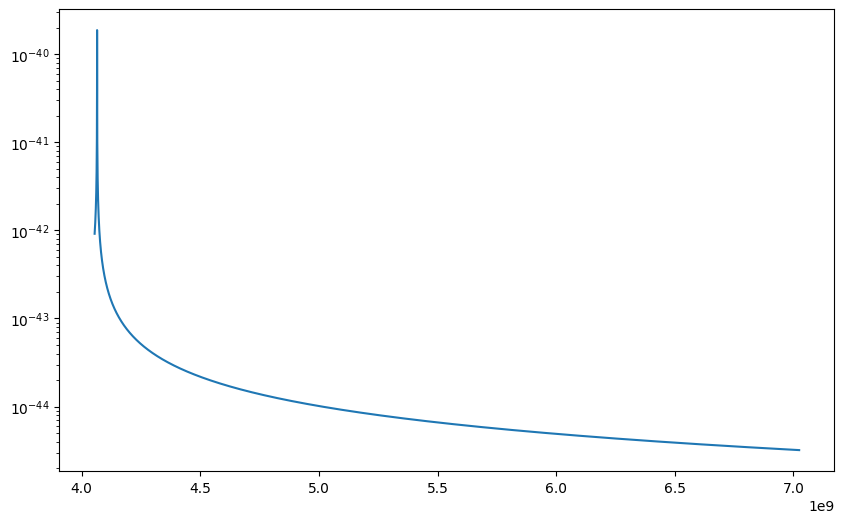

In [ ]:


M = 1e-6      # BH mass in solar masses
M *= 1.1e57 # GeV conversion
r      = 1    # kpc
r *=  1.6e35 # Kpc in GeV^-1
alpha  = 0.3

m_boson = alpha/(G*M) # Boson mass in GeV
   # choose so that f_c ~ 1e3
q      = 0.1 # Binary mass ratio
m_i    = 1
m_f    = -1 # Quantum Numbers
eta = eta_parameter(alpha, q, M) #eta    = 5.0e-2      # parameter entering z (or leave None to use z_scaling below)
a = a_tilde_crit(m_i, alpha)
Omega0 = Omega_plus(a,r_plus(M,a)) / (2.0/np.pi) # Frequency in Gev
Gamma_abs = super_gamma(2, 1, 1, Omega0, m_boson, M, r, a)    # width |Γ| in Hz (or your freq units)
Omega0_Hz = Omega0*1e23
f = np.linspace(Omega0_Hz*0.635, Omega0_Hz*1.1, 10000)


h_of_iota = htilde_plus(
    f, M, r, alpha, Omega0, q, m_i, m_f, eta, Gamma_abs,
    use_z_scaling=False   # set True to use Eq. (15.5) scaling instead of 15.1
)
print(f'Boson Mass is: {m_boson} GeV \n')
print(f'BH Mass is: {M/1.1e57} solar masses\n')
print(f'Omega0 is: {Omega0*1e23/1e6:.3} MHz')
print(f'Eta is: {eta}')
#print(f'z is: {z}')
iota = 0  # rad
Hf = h_of_iota(iota)

# Plot amplitude
plt.figure(figsize=(10,6))
plt.semilogy(f, np.abs(Hf))
plt.xlabel("Frequency $f$ (Hz)",  fontsize=label_fs)
plt.title( 'Binary Perturbation ', fontsize=title_fs)
plt.xscale('log')
plt.ylabel(r"$|\tilde h_+(f)|$", fontsize=label_fs)
plt.tick_params(axis='both', which='both', labelsize=tick_fs)
plt.grid(True, ls=":")
plt.tight_layout()
plt.show()


These params work well \
Boson Mass is: 4.065197433e-14 GeV \
BH Mass is: 1e-06 solar masses\
Omega0 is: 6.39e+03 MHz